In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("college_feedback_sentiment_dataset.csv")

df.head()

,feedback_id,category,feedback,sentiment
0,1,Faculty,Professors provide useful guidance during proj...,positive
1,2,Faculty,Faculty members are often unavailable when stu...,negative
2,3,Faculty,Professors provide useful guidance during proj...,positive
3,4,Faculty,Some classes rely too much on reading slides,negative
4,5,Faculty,Doubts are not always addressed properly,negative


In [3]:
df.shape

(300, 4)

In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_feedback"] = df["feedback"].apply(clean_text)

df[["feedback", "clean_feedback"]].head(10)

,feedback,clean_feedback
0,Professors provide useful guidance during proj...,professors provide useful guidance during proj...
1,Faculty members are often unavailable when stu...,faculty members are often unavailable when stu...
2,Professors provide useful guidance during proj...,professors provide useful guidance during proj...
3,Some classes rely too much on reading slides,some classes rely too much on reading slides
4,Doubts are not always addressed properly,doubts are not always addressed properly
5,Some teachers do not explain difficult topics ...,some teachers do not explain difficult topics ...
6,Faculty members are often unavailable when stu...,faculty members are often unavailable when stu...
7,Doubts are not always addressed properly,doubts are not always addressed properly
8,Faculty members are often unavailable when stu...,faculty members are often unavailable when stu...
9,The teaching quality in most classes is excellent,the teaching quality in most classes is excellent


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_feedback"])

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (300, 248)


In [6]:
df["sentiment_label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

df[["sentiment", "sentiment_label"]].head(10)

,sentiment,sentiment_label
0,positive,1
1,negative,0
2,positive,1
3,negative,0
4,negative,0
5,negative,0
6,negative,0
7,negative,0
8,negative,0
9,positive,1


In [7]:
from sklearn.model_selection import train_test_split

y = df["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 248)
Testing data: (60, 248)


In [8]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [9]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1 0
 1 1 1 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 1 0 0 1]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [11]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        30
    Positive       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



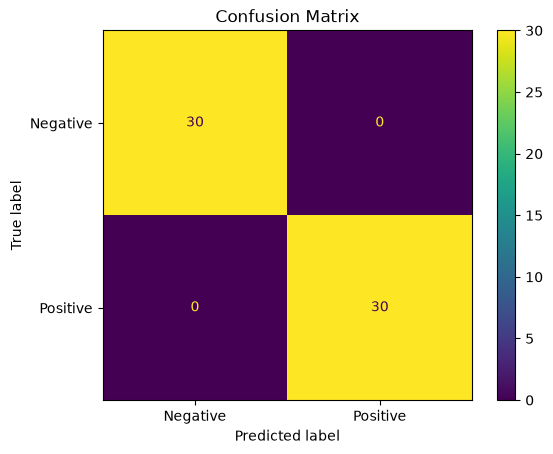

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

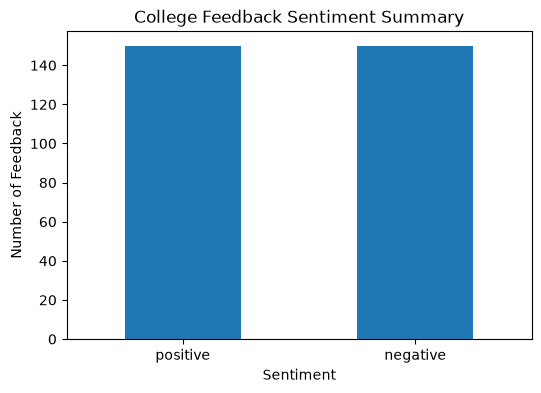

In [13]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind="bar")

plt.title("College Feedback Sentiment Summary")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback")
plt.xticks(rotation=0)

plt.show()

In [14]:
total = len(df)

positive = (df["sentiment"] == "positive").sum()
negative = (df["sentiment"] == "negative").sum()

print("Total Feedback:", total)
print("Positive Feedback:", positive)
print("Negative Feedback:", negative)

print("Positive Percentage:", round((positive / total) * 100, 2), "%")
print("Negative Percentage:", round((negative / total) * 100, 2), "%")

Total Feedback: 300
Positive Feedback: 150
Negative Feedback: 150
Positive Percentage: 50.0 %
Negative Percentage: 50.0 %


In [15]:
new_feedback = input("Enter college feedback: ")

cleaned_feedback = clean_text(new_feedback)

feedback_tfidf = vectorizer.transform([cleaned_feedback])

prediction = model.predict(feedback_tfidf)[0]

if prediction == 1:
    print("Sentiment: POSITIVE")
else:
    print("Sentiment: NEGATIVE")

Sentiment: POSITIVE
